In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

                 tic  sector_length   st_tmag    st_rad   st_mass    st_teff
0      TIC 359185852            2.0  11.20890  0.205115  0.174075  3143.0000
1      TIC 447382925            2.0  11.32340  0.205760  0.174719  3249.0000
2      TIC 206402318            4.0  11.41040  0.183439  0.152950  3125.0000
3      TIC 437041669            3.0  11.35860  0.182223  0.151795  3078.0000
4      TIC 207339173            6.0  11.43570  0.196289  0.165349  3152.0000
...              ...            ...       ...       ...       ...        ...
11499  TIC 108590480            1.0   8.64170  3.125730  1.470000  6808.0000
11500   TIC 45313434            3.0   9.51100  2.331670  1.340000  6519.2798
11501   TIC 83795958            3.0   8.56502  4.535120  1.426000  6710.0000
11502  TIC 451299978            2.0   8.18400  4.167920  1.480000  6846.0000
11503  TIC 337025463            2.0   8.47670  4.160480  1.500000  6906.4702

[11504 rows x 6 columns]


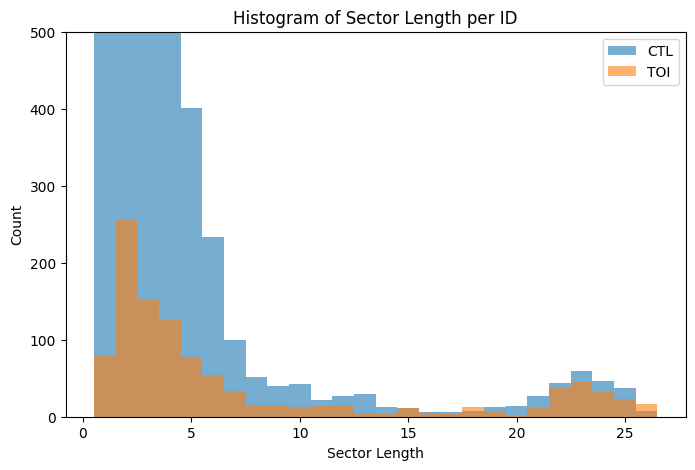

Number of TOIs with sector length 18: 16
Number of CTLs with sector length 18: 8


In [3]:
CTL_sectors = pd.read_csv("CTL_10x_with_sectors.csv")
print(CTL_sectors)
TOI_sectors = pd.read_csv("TOI_sector_results.csv")
plt.figure(figsize=(8, 5))
plt.hist(CTL_sectors['sector_length'], bins=np.arange(0.5, CTL_sectors['sector_length'].max()+1.5, 1), alpha=0.6, label='CTL')
plt.hist(TOI_sectors['sector_length'], bins=np.arange(0.5, TOI_sectors['sector_length'].max()+1.5, 1), alpha=0.6, label='TOI')
plt.xlabel('Sector Length')
plt.ylabel('Count')
plt.title('Histogram of Sector Length per ID')
plt.legend()
plt.ylim(0,500)
plt.show()

num_tois_sector18 = (TOI_sectors['sector_length'] == 26).sum()
print(f"Number of TOIs with sector length 18: {num_tois_sector18}")

num_clts_sector18 = (CTL_sectors['sector_length'] == 26).sum()
print(f"Number of CTLs with sector length 18: {num_clts_sector18}")


TOIs in 3000-3500K: 65
CTLs in 3000-3500K: 50


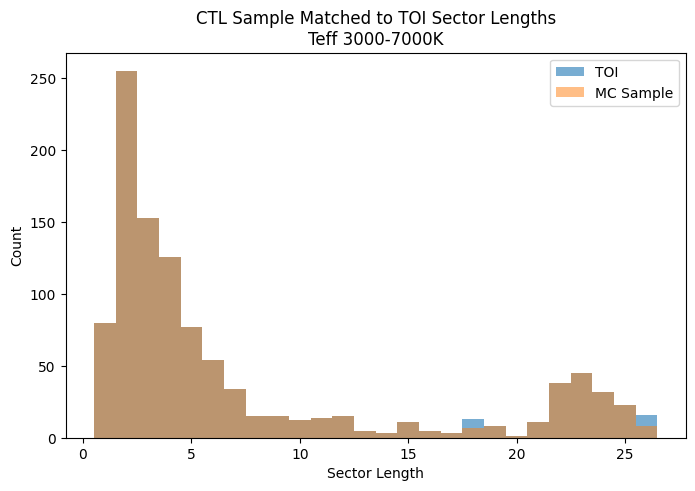

TOI ratio (20-26 / 0-7): 0.21, 166/779
CTL ratio (20-26 / 0-7): 0.20, 158/779


In [4]:
# For each sector_length in TOI_sectors, randomly sample a CTL star with the same sector_length
np.random.seed(5)  # for reproducibility, used 2 for take_two

sampled_ctl_indices = []
used_indices = set()
for sector_len in TOI_sectors['sector_length']:
    matches = CTL_sectors[(CTL_sectors['sector_length'] == sector_len) & (~CTL_sectors.index.isin(used_indices))]
    if not matches.empty:
        sampled_idx = matches.sample(1).index[0]
        sampled_ctl_indices.append(sampled_idx)
        used_indices.add(sampled_idx)

ctl_matched_sample = CTL_sectors.loc[sampled_ctl_indices]

# Filter both TOI_sectors and ctl_matched_sample for Teff between 3000K and 3500K
toi_3000_3500 = TOI_sectors[(TOI_sectors['st_teff'] >= 3000) & (TOI_sectors['st_teff'] < 3500)]
ctl_3000_3500 = ctl_matched_sample[(ctl_matched_sample['st_teff'] >= 3000) & (ctl_matched_sample['st_teff'] < 3500)]

print(f"TOIs in 3000-3500K: {len(toi_3000_3500)}")
print(f"CTLs in 3000-3500K: {len(ctl_3000_3500)}")

# Define temperature range for histograms
teff_min = 3000  
teff_max = 7000

# Filter for the chosen Teff range
toi_temp_range = TOI_sectors[(TOI_sectors['st_teff'] >= teff_min) & (TOI_sectors['st_teff'] < teff_max)]
ctl_temp_range = ctl_matched_sample[(ctl_matched_sample['st_teff'] >= teff_min) & (ctl_matched_sample['st_teff'] < teff_max)]

plt.figure(figsize=(8, 5))
plt.hist(toi_temp_range['sector_length'], bins=np.arange(0.5, toi_temp_range['sector_length'].max()+1.5, 1), 
         alpha=0.6, label=f'TOI')
plt.hist(ctl_temp_range['sector_length'], bins=np.arange(0.5, ctl_temp_range['sector_length'].max()+1.5, 1), 
         alpha=0.5, label=f'MC Sample')

plt.xlabel('Sector Length')
plt.ylabel('Count')
plt.title(f'CTL Sample Matched to TOI Sector Lengths\nTeff {teff_min}-{teff_max}K')
plt.legend()
plt.show()

num_toi_20_26 = toi_temp_range[(toi_temp_range['sector_length'] >= 20) & (toi_temp_range['sector_length'] <= 26)].shape[0]
num_ctl_20_26 = ctl_temp_range[(ctl_temp_range['sector_length'] >= 20) & (ctl_temp_range['sector_length'] <= 26)].shape[0]



num_toi_0_7 = toi_temp_range[(toi_temp_range['sector_length'] >= 0) & (toi_temp_range['sector_length'] <= 7)].shape[0]
num_ctl_0_7 = ctl_temp_range[(ctl_temp_range['sector_length'] >= 0) & (ctl_temp_range['sector_length'] <= 7)].shape[0]

# Flip 0-5 and 20-25 in the ratio calculations
ratio_toi = num_toi_20_26 / num_toi_0_7 
ratio_ctl = num_ctl_20_26 / num_ctl_0_7 

print(f"TOI ratio (20-26 / 0-7): {ratio_toi:.2f}, {num_toi_20_26}/{num_toi_0_7}")
print(f"CTL ratio (20-26 / 0-7): {ratio_ctl:.2f}, {num_ctl_20_26}/{num_ctl_0_7}")


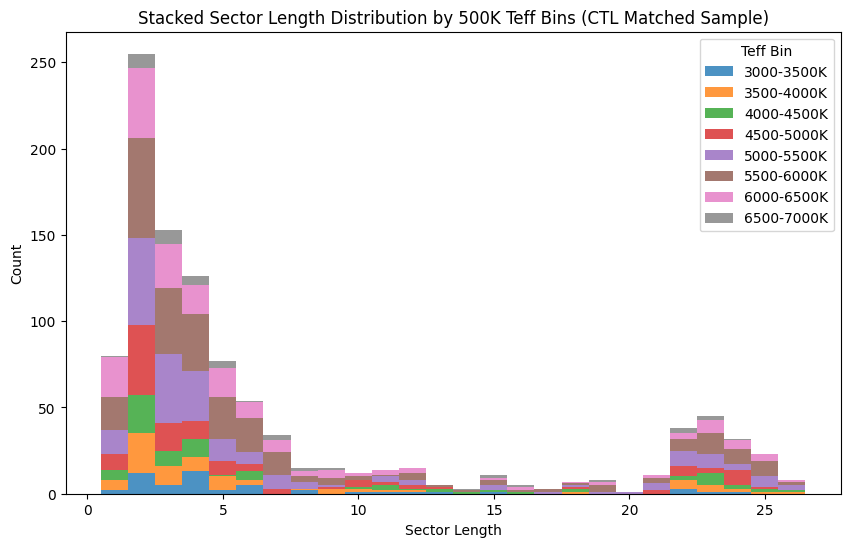

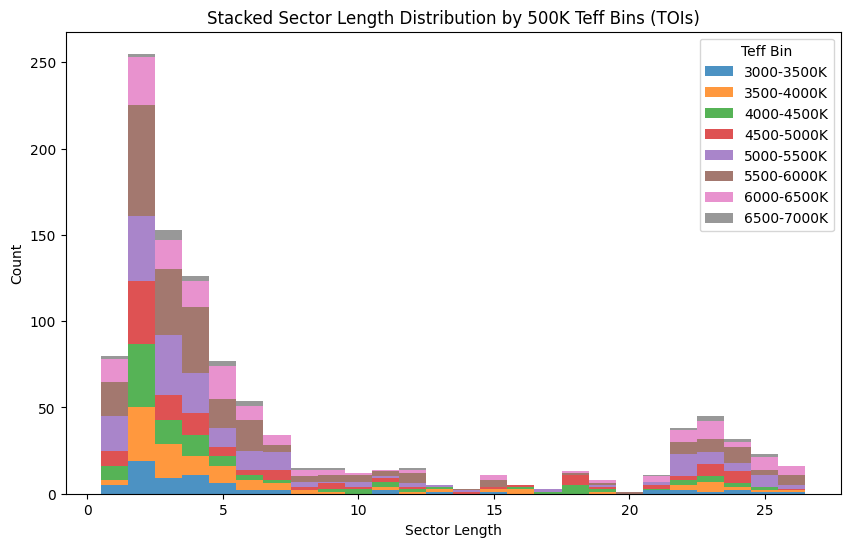

In [5]:
# Bin st_teff in 500K bins and plot sector_length distribution per bin
bins = np.arange(ctl_matched_sample['st_teff'].min() // 500 * 500, ctl_matched_sample['st_teff'].max() + 500, 500)
labels = [f"{int(bins[i])}-{int(bins[i+1])}K" for i in range(len(bins)-1)]
ctl_matched_sample['teff_bin'] = pd.cut(ctl_matched_sample['st_teff'], bins=bins, labels=labels, include_lowest=True)

# Bin st_teff in 500K bins and plot sector_length distribution per bin as a stacked histogram
plt.figure(figsize=(10, 6))
bin_data = [ctl_matched_sample[ctl_matched_sample['teff_bin'] == label]['sector_length'] for label in labels]
plt.hist(bin_data, bins=np.arange(0.5, ctl_matched_sample['sector_length'].max()+1.5, 1), stacked=True, label=labels, alpha=0.8)
plt.xlabel('Sector Length')
plt.ylabel('Count')
plt.title('Stacked Sector Length Distribution by 500K Teff Bins (CTL Matched Sample)')
plt.legend(title='Teff Bin')
plt.show()

# Bin st_teff in 500K bins and plot sector_length distribution per bin for TOIs
bins_toi = np.arange(TOI_sectors['st_teff'].min() // 500 * 500, TOI_sectors['st_teff'].max() + 500, 500)
labels_toi = [f"{int(bins_toi[i])}-{int(bins_toi[i+1])}K" for i in range(len(bins_toi)-1)]
TOI_sectors['teff_bin'] = pd.cut(TOI_sectors['st_teff'], bins=bins_toi, labels=labels_toi, include_lowest=True)

plt.figure(figsize=(10, 6))
bin_data_toi = [TOI_sectors[TOI_sectors['teff_bin'] == label]['sector_length'] for label in labels_toi]
plt.hist(bin_data_toi, bins=np.arange(0.5, TOI_sectors['sector_length'].max()+1.5, 1), stacked=True, label=labels_toi, alpha=0.8)
plt.xlabel('Sector Length')
plt.ylabel('Count')
plt.title('Stacked Sector Length Distribution by 500K Teff Bins (TOIs)')
plt.legend(title='Teff Bin')
plt.show()

     teff_bin   ks_stat   p_value  n_toi  n_ctl
0  3000-3500K  0.119988  0.741865     67     51
1  3500-4000K  0.054453  0.997004    112     81
2  4000-4500K  0.088053  0.819681    113     80
3  4500-5000K  0.070286  0.886240    124    123
4  5000-5500K  0.050488  0.938897    199    212
5  5500-6000K  0.075239  0.409045    260    274
6  6000-6500K  0.119398  0.158569    158    185
7  6500-7000K  0.157625  0.683836     31     44


/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_66148/927528780.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ks_df['teff_bin'], rotation=45)


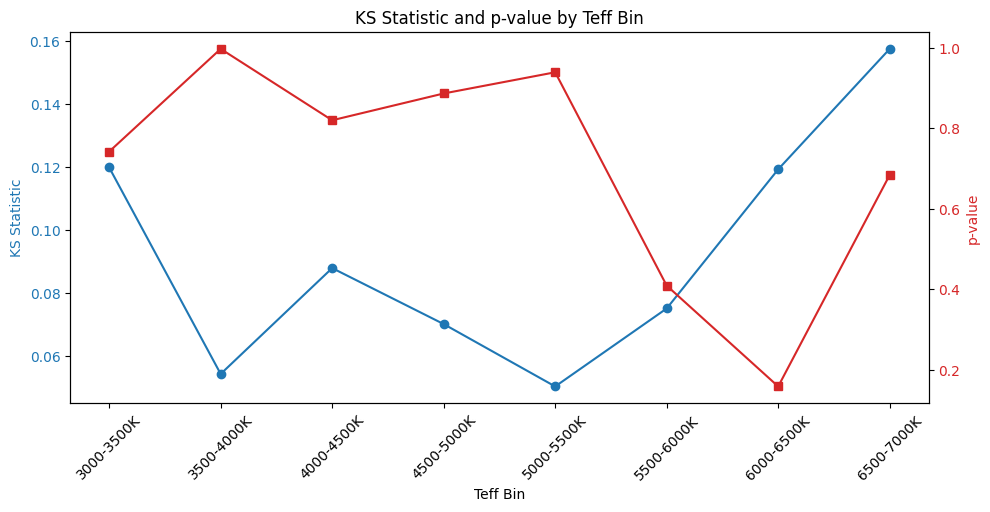

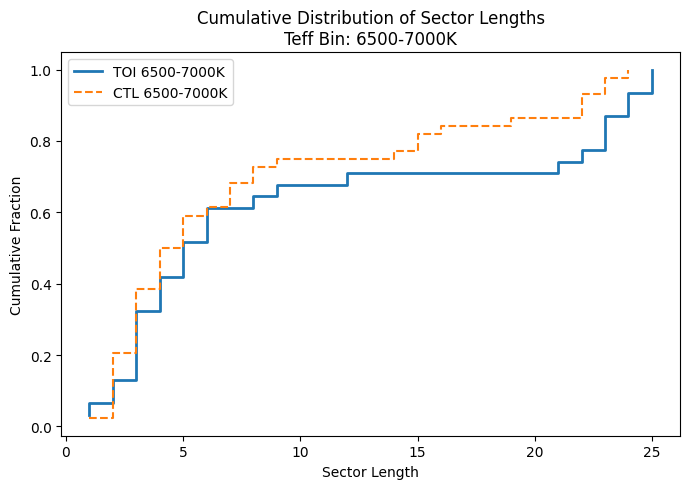

In [6]:
from scipy.stats import ks_2samp

ks_results = []

for label in labels:
    toi_bin = TOI_sectors[TOI_sectors['teff_bin'] == label]['sector_length']
    ctl_bin = ctl_matched_sample[ctl_matched_sample['teff_bin'] == label]['sector_length']
    if len(toi_bin) > 0 and len(ctl_bin) > 0:
        ks_stat, p_val = ks_2samp(toi_bin, ctl_bin)
        ks_results.append({'teff_bin': label, 'ks_stat': ks_stat, 'p_value': p_val, 
                           'n_toi': len(toi_bin), 'n_ctl': len(ctl_bin)})
    else:
        ks_results.append({'teff_bin': label, 'ks_stat': np.nan, 'p_value': np.nan, 
                           'n_toi': len(toi_bin), 'n_ctl': len(ctl_bin)})

ks_df = pd.DataFrame(ks_results)
print(ks_df)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Teff Bin')
ax1.set_ylabel('KS Statistic', color=color)
ax1.plot(ks_df['teff_bin'], ks_df['ks_stat'], marker='o', color=color, label='KS Statistic')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(ks_df['teff_bin'], rotation=45)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('p-value', color=color)
ax2.plot(ks_df['teff_bin'], ks_df['p_value'], marker='s', color=color, label='p-value')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('KS Statistic and p-value by Teff Bin')
plt.show()

# Allow user to easily pick a Teff bin to view cumulative distributions
def plot_cumulative_for_bin(teff_bin_label):
    toi_bin = TOI_sectors[TOI_sectors['teff_bin'] == teff_bin_label]['sector_length']
    ctl_bin = ctl_matched_sample[ctl_matched_sample['teff_bin'] == teff_bin_label]['sector_length']
    if len(toi_bin) == 0 or len(ctl_bin) == 0:
        print(f"No data for Teff bin: {teff_bin_label}")
        return
    toi_sorted = np.sort(toi_bin)
    ctl_sorted = np.sort(ctl_bin)
    toi_cum = np.arange(1, len(toi_sorted)+1) / len(toi_sorted)
    ctl_cum = np.arange(1, len(ctl_sorted)+1) / len(ctl_sorted)
    plt.figure(figsize=(7, 5))
    plt.step(toi_sorted, toi_cum, where='post', label=f'TOI {teff_bin_label}', linewidth=2)
    plt.step(ctl_sorted, ctl_cum, where='post', label=f'CTL {teff_bin_label}', linestyle='--')
    plt.xlabel('Sector Length')
    plt.ylabel('Cumulative Fraction')
    plt.title(f'Cumulative Distribution of Sector Lengths\nTeff Bin: {teff_bin_label}')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage:
plot_cumulative_for_bin('6500-7000K')

In [7]:
# ctl_matched_sample = ctl_matched_sample.rename(
#     columns={
#         'tic': 'id',
#         'st_rad': 'RAD',
#         'st_mass': 'MASS',
#         'st_teff': 'teff',
#         'st_tmag': 'tmag',
#         'sector_length': 'sector_length'
#     }
# )

# ctl_matched_sample['id'] = ctl_matched_sample['id'].str.replace('TIC ', '').astype(int)

# print(ctl_matched_sample)



1064 1050

TOI Summary:
  Tmag: 10.32 ± 1.45
  Radius: 0.852 ± 0.389 R☉
  Teff: 5310 ± 924 K
  Sector Length: 4.0 ± 7.7

CTL Matched Sample Summary:
  Tmag: 10.22 ± 1.25
  Radius: 0.875 ± 0.341 R☉
  Teff: 5451 ± 880 K
  Sector Length: 4.0 ± 7.5


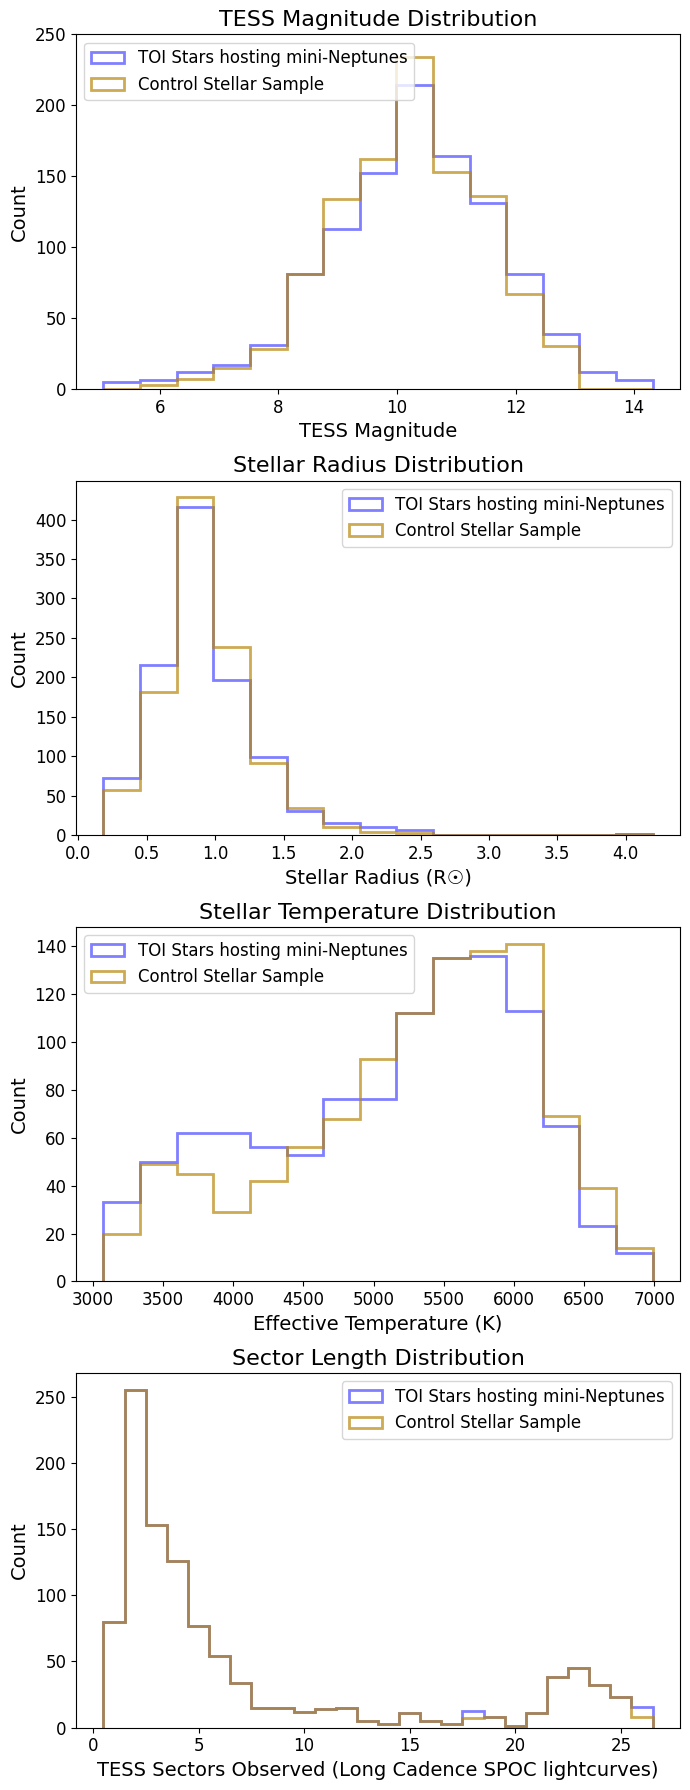

In [8]:
fig, axes = plt.subplots(4,1, figsize=(7, 18))
print(len(TOI_sectors), len(ctl_matched_sample))

# Flatten axes for easier indexing
axes = axes.flatten()

# st_tmag histogram
tmag_bins = np.linspace(
    min(TOI_sectors['st_tmag'].min(), ctl_matched_sample['st_tmag'].min()),
    max(TOI_sectors['st_tmag'].max(), ctl_matched_sample['st_tmag'].max()),
    16
)
axes[0].hist(TOI_sectors['st_tmag'], bins=tmag_bins, histtype='step', linewidth=2, alpha=0.5, color='blue', label='TOI Stars hosting mini-Neptunes')
axes[0].hist(ctl_matched_sample['st_tmag'], bins=tmag_bins, histtype='step', linewidth=2, alpha=0.7, color='darkgoldenrod', label='Control Stellar Sample')
axes[0].set_xlabel('TESS Magnitude', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].set_title('TESS Magnitude Distribution', fontsize=16)
axes[0].legend(fontsize=12)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].set_ylim(0,250)

# st_rad histogram
rad_bins = np.linspace(
    min(TOI_sectors['st_rad'].min(), ctl_matched_sample['st_rad'].min()),
    max(TOI_sectors['st_rad'].max(), ctl_matched_sample['st_rad'].max()),
    16
)
axes[1].hist(TOI_sectors['st_rad'], bins=rad_bins, histtype='step', linewidth=2, alpha=0.5, color='blue', label='TOI Stars hosting mini-Neptunes')
axes[1].hist(ctl_matched_sample['st_rad'], bins=rad_bins, histtype='step', linewidth=2, alpha=0.7, color='darkgoldenrod', label='Control Stellar Sample')
axes[1].set_xlabel('Stellar Radius (R☉)', fontsize=14)
axes[1].set_ylabel('Count', fontsize=14)
axes[1].set_title('Stellar Radius Distribution', fontsize=16)
axes[1].legend(fontsize=12)
axes[1].tick_params(axis='both', labelsize=12)

# st_teff histogram
teff_bins = np.linspace(
    min(TOI_sectors['st_teff'].min(), ctl_matched_sample['st_teff'].min()),
    max(TOI_sectors['st_teff'].max(), ctl_matched_sample['st_teff'].max()),
    16
)
axes[2].hist(TOI_sectors['st_teff'], bins=teff_bins, histtype='step', linewidth=2, alpha=0.5, color='blue', label='TOI Stars hosting mini-Neptunes')
axes[2].hist(ctl_matched_sample['st_teff'], bins=teff_bins, histtype='step', linewidth=2, alpha=0.7, color='darkgoldenrod', label='Control Stellar Sample')
axes[2].set_xlabel('Effective Temperature (K)', fontsize=14)
axes[2].set_ylabel('Count', fontsize=14)
axes[2].set_title('Stellar Temperature Distribution', fontsize=16)
axes[2].legend(fontsize=12)
axes[2].tick_params(axis='both', labelsize=12)

# sector_length histogram
sector_bins = np.arange(0.5, max(TOI_sectors['sector_length'].max(), ctl_matched_sample['sector_length'].max())+1.5, 1)
axes[3].hist(TOI_sectors['sector_length'], bins=sector_bins, histtype='step', linewidth=2, alpha=0.5, color='blue', label='TOI Stars hosting mini-Neptunes')
axes[3].hist(ctl_matched_sample['sector_length'], bins=sector_bins, histtype='step', linewidth=2, alpha=0.7, color='darkgoldenrod', label='Control Stellar Sample')
axes[3].set_xlabel('TESS Sectors Observed (Long Cadence SPOC lightcurves)', fontsize=14)
axes[3].set_ylabel('Count', fontsize=14)
axes[3].set_title('Sector Length Distribution', fontsize=16)
axes[3].legend(fontsize=12)
axes[3].tick_params(axis='both', labelsize=12)

plt.tight_layout()
#plt.show()

# Print summary statistics
print("\nTOI Summary:")
print(f"  Tmag: {TOI_sectors['st_tmag'].median():.2f} ± {TOI_sectors['st_tmag'].std():.2f}")
print(f"  Radius: {TOI_sectors['st_rad'].median():.3f} ± {TOI_sectors['st_rad'].std():.3f} R☉")
print(f"  Teff: {TOI_sectors['st_teff'].median():.0f} ± {TOI_sectors['st_teff'].std():.0f} K")
print(f"  Sector Length: {TOI_sectors['sector_length'].median():.1f} ± {TOI_sectors['sector_length'].std():.1f}")

print("\nCTL Matched Sample Summary:")
print(f"  Tmag: {ctl_matched_sample['st_tmag'].median():.2f} ± {ctl_matched_sample['st_tmag'].std():.2f}")
print(f"  Radius: {ctl_matched_sample['st_rad'].median():.3f} ± {ctl_matched_sample['st_rad'].std():.3f} R☉")
print(f"  Teff: {ctl_matched_sample['st_teff'].median():.0f} ± {ctl_matched_sample['st_teff'].std():.0f} K")
print(f"  Sector Length: {ctl_matched_sample['sector_length'].median():.1f} ± {ctl_matched_sample['sector_length'].std():.1f}")


plt.savefig('stellar_parameters_comparison.png', dpi=300, bbox_inches='tight')


1064 1050
Found 791 TIC IDs
[1008059, 1354707, 2854230, 2886827, 3358442, 3808984, 4053416, 4166514, 4339524, 4695190]

TOI Summary:
  Tmag: 10.32 ± 1.45
  Radius: 0.852 ± 0.389 R☉
  Teff: 5310 ± 924 K
  Sector Length: 4.0 ± 7.7

CTL Matched Sample Summary:
  Tmag: 10.22 ± 1.25
  Radius: 0.875 ± 0.341 R☉
  Teff: 5451 ± 880 K
  Sector Length: 4.0 ± 7.5


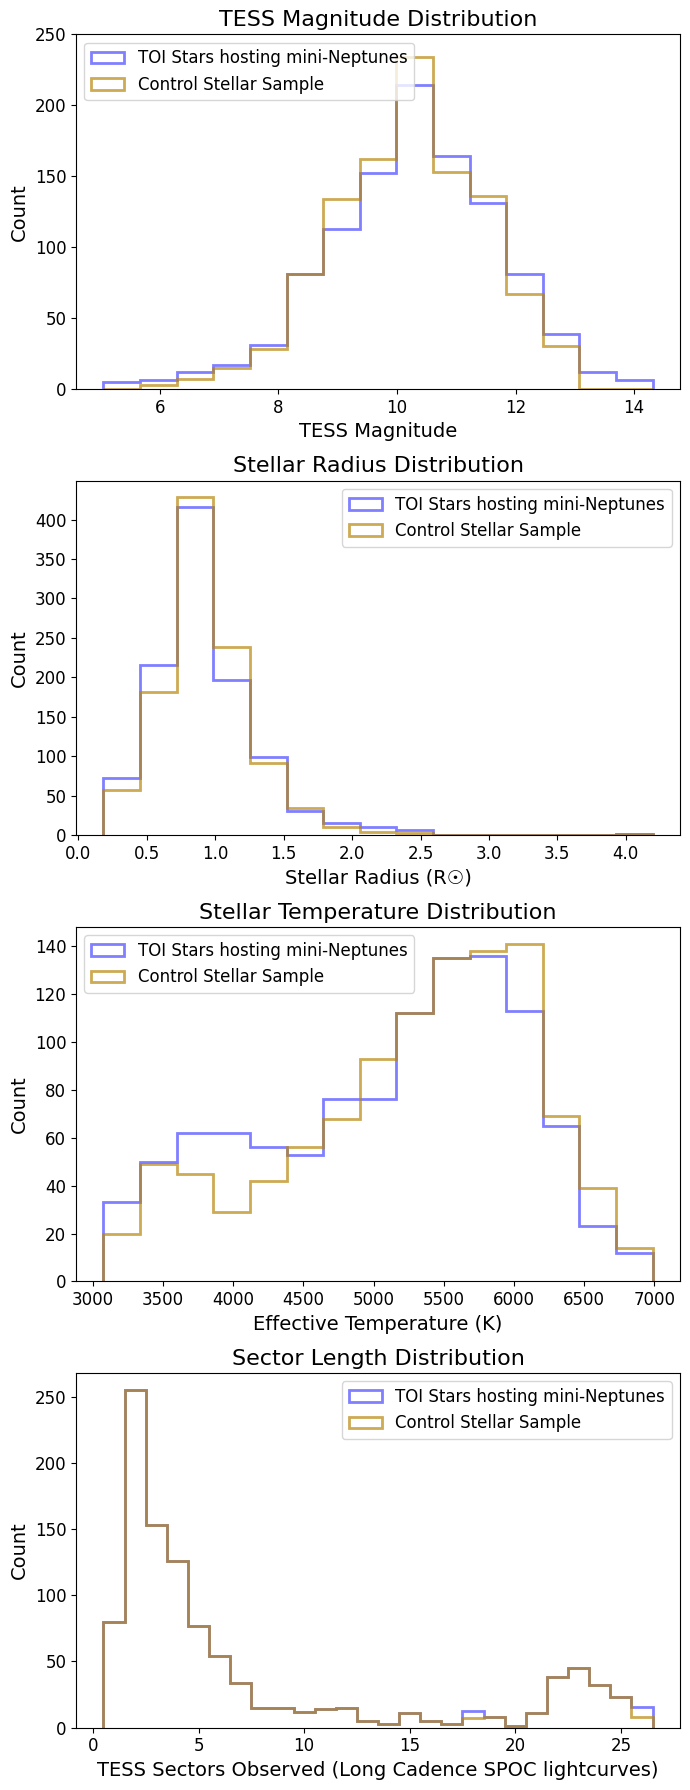

In [9]:
from pathlib import Path
import re

fig, axes = plt.subplots(4,1, figsize=(7, 18))

tic_dir = Path("/Users/danayaptangco/local_code/Mulders/main_proj/tess_demographics/gen_heatmaps/inj_rec/inj_rec_results/take_two_tls_results_per_tic")
print(len(TOI_sectors), len(ctl_matched_sample))

# Get TIC IDs from filenames in the directory (extract first number in each stem)
tic_ids = sorted({
    int(match.group(1))
    for f in tic_dir.iterdir()
    if f.is_file()
    for match in [re.search(r"(\d+)", f.stem)]
    if match
})

print(f"Found {len(tic_ids)} TIC IDs")
print(tic_ids[:10])  # preview

# st_tmag histogram
tmag_bins = np.linspace(
    min(TOI_sectors['st_tmag'].min(), ctl_matched_sample['st_tmag'].min()),
    max(TOI_sectors['st_tmag'].max(), ctl_matched_sample['st_tmag'].max()),
    16
)
axes[0].hist(TOI_sectors['st_tmag'], bins=tmag_bins, histtype='step', linewidth=2, alpha=0.5, color='blue', label='TOI Stars hosting mini-Neptunes')
axes[0].hist(ctl_matched_sample['st_tmag'], bins=tmag_bins, histtype='step', linewidth=2, alpha=0.7, color='darkgoldenrod', label='Control Stellar Sample')
axes[0].set_xlabel('TESS Magnitude', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].set_title('TESS Magnitude Distribution', fontsize=16)
axes[0].legend(fontsize=12)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].set_ylim(0,250)

# st_rad histogram
rad_bins = np.linspace(
    min(TOI_sectors['st_rad'].min(), ctl_matched_sample['st_rad'].min()),
    max(TOI_sectors['st_rad'].max(), ctl_matched_sample['st_rad'].max()),
    16
)
axes[1].hist(TOI_sectors['st_rad'], bins=rad_bins, histtype='step', linewidth=2, alpha=0.5, color='blue', label='TOI Stars hosting mini-Neptunes')
axes[1].hist(ctl_matched_sample['st_rad'], bins=rad_bins, histtype='step', linewidth=2, alpha=0.7, color='darkgoldenrod', label='Control Stellar Sample')
axes[1].set_xlabel('Stellar Radius (R☉)', fontsize=14)
axes[1].set_ylabel('Count', fontsize=14)
axes[1].set_title('Stellar Radius Distribution', fontsize=16)
axes[1].legend(fontsize=12)
axes[1].tick_params(axis='both', labelsize=12)

# st_teff histogram
teff_bins = np.linspace(
    min(TOI_sectors['st_teff'].min(), ctl_matched_sample['st_teff'].min()),
    max(TOI_sectors['st_teff'].max(), ctl_matched_sample['st_teff'].max()),
    16
)
axes[2].hist(TOI_sectors['st_teff'], bins=teff_bins, histtype='step', linewidth=2, alpha=0.5, color='blue', label='TOI Stars hosting mini-Neptunes')
axes[2].hist(ctl_matched_sample['st_teff'], bins=teff_bins, histtype='step', linewidth=2, alpha=0.7, color='darkgoldenrod', label='Control Stellar Sample')
axes[2].set_xlabel('Effective Temperature (K)', fontsize=14)
axes[2].set_ylabel('Count', fontsize=14)
axes[2].set_title('Stellar Temperature Distribution', fontsize=16)
axes[2].legend(fontsize=12)
axes[2].tick_params(axis='both', labelsize=12)

# sector_length histogram
sector_bins = np.arange(0.5, max(TOI_sectors['sector_length'].max(), ctl_matched_sample['sector_length'].max())+1.5, 1)
axes[3].hist(TOI_sectors['sector_length'], bins=sector_bins, histtype='step', linewidth=2, alpha=0.5, color='blue', label='TOI Stars hosting mini-Neptunes')
axes[3].hist(ctl_matched_sample['sector_length'], bins=sector_bins, histtype='step', linewidth=2, alpha=0.7, color='darkgoldenrod', label='Control Stellar Sample')
axes[3].set_xlabel('TESS Sectors Observed (Long Cadence SPOC lightcurves)', fontsize=14)
axes[3].set_ylabel('Count', fontsize=14)
axes[3].set_title('Sector Length Distribution', fontsize=16)
axes[3].legend(fontsize=12)
axes[3].tick_params(axis='both', labelsize=12)

plt.tight_layout()
#plt.show()

# Print summary statistics
print("\nTOI Summary:")
print(f"  Tmag: {TOI_sectors['st_tmag'].median():.2f} ± {TOI_sectors['st_tmag'].std():.2f}")
print(f"  Radius: {TOI_sectors['st_rad'].median():.3f} ± {TOI_sectors['st_rad'].std():.3f} R☉")
print(f"  Teff: {TOI_sectors['st_teff'].median():.0f} ± {TOI_sectors['st_teff'].std():.0f} K")
print(f"  Sector Length: {TOI_sectors['sector_length'].median():.1f} ± {TOI_sectors['sector_length'].std():.1f}")

print("\nCTL Matched Sample Summary:")
print(f"  Tmag: {ctl_matched_sample['st_tmag'].median():.2f} ± {ctl_matched_sample['st_tmag'].std():.2f}")
print(f"  Radius: {ctl_matched_sample['st_rad'].median():.3f} ± {ctl_matched_sample['st_rad'].std():.3f} R☉")
print(f"  Teff: {ctl_matched_sample['st_teff'].median():.0f} ± {ctl_matched_sample['st_teff'].std():.0f} K")
print(f"  Sector Length: {ctl_matched_sample['sector_length'].median():.1f} ± {ctl_matched_sample['sector_length'].std():.1f}")


plt.savefig('stellar_parameters_comparison.png', dpi=300, bbox_inches='tight')


Filtered stellar params: 791 
          id  sector_length     tmag       RAD   MASS       teff    teff_bin
0   51988363            2.0   9.5563  1.182280  1.020  5720.0000  5500-6000K
1  172076858            4.0  10.5804  0.813724  0.880  5186.0000  5000-5500K
2  140067408            2.0   9.8744  0.973123  1.000  5656.0000  5500-6000K
3  284566637            5.0  10.7167  1.218320  1.131  6062.8799  6000-6500K
4   11148069            4.0  10.0391  0.735781  0.840  5044.0000  5000-5500K
Filtered TOI sector results: 678 rows
        toi            tic  sector_length  st_tmag   st_rad  st_mass  st_teff
0   5165.01  TIC 349986198              2  12.5389  0.87000    0.740  4642.10
5   6944.01  TIC 421005422              1  10.7077  0.76000    0.879  5181.10
8   5319.01  TIC 246965431              3  12.0828  0.48000    0.500  3580.00
9   5082.01  TIC 437011608              2   7.6253  0.93000    1.010  5670.00
10  6054.01  TIC 392681545              1   7.4961  1.61211    1.150  6111.67
67

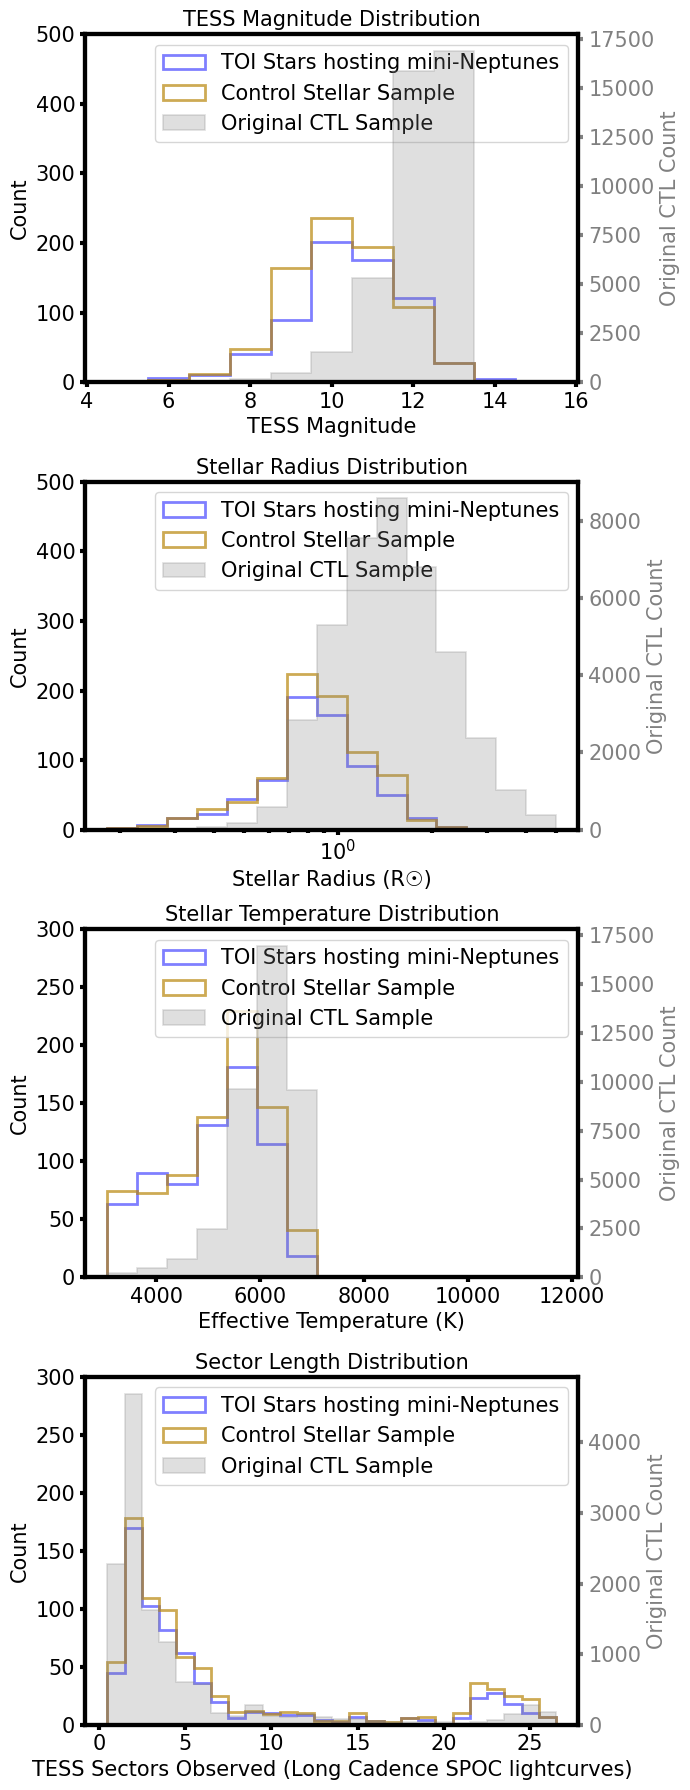

In [16]:
plt.rcParams.update({'lines.linewidth': 3, 'axes.linewidth': 3, 'grid.linewidth': 3, 'xtick.major.width': 3, 'ytick.major.width': 3, 'xtick.minor.width': 3, 'ytick.minor.width': 3})

stellar_params = Path("/Users/danayaptangco/local_code/Mulders/main_proj/tess_demographics/control_sample/take_two_stellar_params_CTL.csv")
stellar_params_df = pd.read_csv(stellar_params)

control_sample = Path("/Users/danayaptangco/local_code/Mulders/main_proj/tess_demographics/gen_heatmaps/inj_rec/inj_rec_results/take_two_tls_results_per_tic")

# Load original CTL parent sample (pre-matching)
original_ctl = pd.read_csv("/Users/danayaptangco/local_code/Mulders/main_proj/tess_demographics/control_sample/CTL_2025April_with_sectors.csv")


def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")


# Resolve column names robustly across catalog variants
orig_tmag_col = pick_col(original_ctl, ['tmag', 'st_tmag'])
orig_rad_col = pick_col(original_ctl, ['RAD', 'st_rad', 'rad'])
orig_teff_col = pick_col(original_ctl, ['teff', 'st_teff'])
orig_sector_col = pick_col(original_ctl, ['sector_length'])

# Get TIC IDs from filenames in the directory
tic_ids = sorted({
    int(match.group(1))
    for f in control_sample.iterdir()
    if f.is_file()
    for match in [re.search(r"(\d+)", f.stem)]
    if match
})

# Filter stellar_params to only keep rows where id is in tic_ids
control_stellar_params = stellar_params_df[stellar_params_df['id'].isin(tic_ids)]
print(f"Filtered stellar params: {len(control_stellar_params)} ")
print(control_stellar_params.head())


toi_sector_results = pd.read_csv("/Users/danayaptangco/local_code/Mulders/main_proj/tess_demographics/control_sample/TOI_sector_results.csv")

toi_stellar_params = Path("/Users/danayaptangco/local_code/Mulders/main_proj/tess_demographics/gen_heatmaps/inj_rec/inj_rec_results/TOI_Mar2025_1pt5to4_R_detected_real_only.csv")
toi_stellar_params_df = pd.read_csv(toi_stellar_params)

toi_stellar_params_df = toi_stellar_params_df.dropna(subset=['st_teff', 'pl_rade', 'mst'])
toi_stellar_params_df = toi_stellar_params_df[(toi_stellar_params_df['pl_rade'] > 1.8) & (toi_stellar_params_df['pl_rade'] < 4.0)]
toi_stellar_params_df = toi_stellar_params_df[(toi_stellar_params_df['pl_orbper'] > 0.531) & (toi_stellar_params_df['pl_orbper'] < 25.1)]
if 'tfopwg_disp' in toi_stellar_params_df.columns:
    toi_stellar_params_df = toi_stellar_params_df[toi_stellar_params_df['tfopwg_disp'] != 'FP']

# Filter toi_sector_results to only keep rows where 'toi' exists in toi_stellar_params_df
toi_sector_results = toi_sector_results[toi_sector_results['toi'].isin(toi_stellar_params_df['TOI'])]

print(f"Filtered TOI sector results: {len(toi_sector_results)} rows")
print(toi_sector_results.head())


# Merge TOI stellar params with sector information
toi_stellar_params_df = toi_stellar_params_df.merge(
    toi_sector_results[['toi', 'sector_length']], 
    left_on='TOI', 
    right_on='toi', 
    how='left'
)

fig, axes = plt.subplots(4, 1, figsize=(7, 18))

# st_tmag histogram
tmag_bins = np.linspace(
    4.5, 15.5,
    12
)

print(len(toi_stellar_params_df), len(control_stellar_params), len(original_ctl))
axes[0].hist(toi_stellar_params_df['st_tmag'], bins=tmag_bins, histtype='step', linewidth=2, alpha=0.5, color='blue', label='TOI Stars hosting mini-Neptunes')
axes[0].hist(control_stellar_params['tmag'], bins=tmag_bins, histtype='step', linewidth=2, alpha=0.7, color='darkgoldenrod', label='Control Stellar Sample')
ax0b = axes[0].twinx()
ax0b.hist(original_ctl[orig_tmag_col], bins=tmag_bins, histtype='stepfilled', linewidth=1.2, alpha=0.25, color='gray', edgecolor='gray', label='Original CTL Sample')
ax0b.set_ylabel('Original CTL Count', fontsize=15, color='gray')
ax0b.tick_params(axis='y', labelsize=15, colors='gray')
axes[0].set_xlabel('TESS Magnitude', fontsize=15)
axes[0].set_ylabel('Count', fontsize=15)
axes[0].set_title('TESS Magnitude Distribution', fontsize=15)
h0, l0 = axes[0].get_legend_handles_labels()
h0b, l0b = ax0b.get_legend_handles_labels()
axes[0].legend(h0 + h0b, l0 + l0b, fontsize=15)
axes[0].tick_params(axis='both', labelsize=15)
axes[0].set_ylim(0, 500)

# st_rad histogram with log-spaced bins
rad_bins = np.logspace(
    np.log10(min(toi_stellar_params_df['st_rad'].min(), control_stellar_params['RAD'].min(), original_ctl[orig_rad_col].min())),
    np.log10(max(toi_stellar_params_df['st_rad'].max(), control_stellar_params['RAD'].max(), original_ctl[orig_rad_col].max())),
    16
)
axes[1].hist(toi_stellar_params_df['st_rad'], bins=rad_bins, histtype='step', linewidth=2, alpha=0.5, color='blue', label='TOI Stars hosting mini-Neptunes')
axes[1].hist(control_stellar_params['RAD'], bins=rad_bins, histtype='step', linewidth=2, alpha=0.7, color='darkgoldenrod', label='Control Stellar Sample')
ax1b = axes[1].twinx()
ax1b.hist(original_ctl[orig_rad_col], bins=rad_bins, histtype='stepfilled', linewidth=1.2, alpha=0.25, color='gray', edgecolor='gray', label='Original CTL Sample')
ax1b.set_ylabel('Original CTL Count', fontsize=15, color='gray')
ax1b.tick_params(axis='y', labelsize=15, colors='gray')
axes[1].set_xlabel('Stellar Radius (R☉)', fontsize=15)
axes[1].set_ylabel('Count', fontsize=15)
axes[1].set_title('Stellar Radius Distribution', fontsize=15)
h1, l1 = axes[1].get_legend_handles_labels()
h1b, l1b = ax1b.get_legend_handles_labels()
axes[1].legend(h1 + h1b, l1 + l1b, fontsize=15)
axes[1].tick_params(axis='both', labelsize=15)
axes[1].set_xscale('log')
axes[1].set_ylim(0,500)

# st_teff histogram
teff_bins = np.linspace(
    min(toi_stellar_params_df['st_teff'].min(), control_stellar_params['teff'].min(), original_ctl[orig_teff_col].min()),
    max(toi_stellar_params_df['st_teff'].max(), control_stellar_params['teff'].max(), original_ctl[orig_teff_col].max()),
    16
)
axes[2].hist(toi_stellar_params_df['st_teff'], bins=teff_bins, histtype='step', linewidth=2, alpha=0.5, color='blue', label='TOI Stars hosting mini-Neptunes')
axes[2].hist(control_stellar_params['teff'], bins=teff_bins, histtype='step', linewidth=2, alpha=0.7, color='darkgoldenrod', label='Control Stellar Sample')
ax2b = axes[2].twinx()
ax2b.hist(original_ctl[orig_teff_col], bins=teff_bins, histtype='stepfilled', linewidth=1.2, alpha=0.25, color='gray', edgecolor='gray', label='Original CTL Sample')
ax2b.set_ylabel('Original CTL Count', fontsize=15, color='gray')
ax2b.tick_params(axis='y', labelsize=15, colors='gray')
axes[2].set_xlabel('Effective Temperature (K)', fontsize=15)
axes[2].set_ylabel('Count', fontsize=15)
axes[2].set_title('Stellar Temperature Distribution', fontsize=15)
h2, l2 = axes[2].get_legend_handles_labels()
h2b, l2b = ax2b.get_legend_handles_labels()
axes[2].legend(h2 + h2b, l2 + l2b, fontsize=15)
axes[2].tick_params(axis='both', labelsize=15)
axes[2].set_ylim(0,300)

# sector_length histogram
sector_bins = np.arange(
    0.5,
    max(toi_stellar_params_df['sector_length'].max(), control_stellar_params['sector_length'].max(), original_ctl[orig_sector_col].max()) + 1.5,
    1
)
axes[3].hist(toi_stellar_params_df['sector_length'], bins=sector_bins, histtype='step', linewidth=2, alpha=0.5, color='blue', label='TOI Stars hosting mini-Neptunes')
axes[3].hist(control_stellar_params['sector_length'], bins=sector_bins, histtype='step', linewidth=2, alpha=0.7, color='darkgoldenrod', label='Control Stellar Sample')
ax3b = axes[3].twinx()
ax3b.hist(original_ctl[orig_sector_col], bins=sector_bins, histtype='stepfilled', linewidth=1.2, alpha=0.25, color='gray', edgecolor='gray', label='Original CTL Sample')
ax3b.set_ylabel('Original CTL Count', fontsize=15, color='gray')
ax3b.tick_params(axis='y', labelsize=15, colors='gray')
axes[3].set_xlabel('TESS Sectors Observed (Long Cadence SPOC lightcurves)', fontsize=15)
axes[3].set_ylabel('Count', fontsize=15)
axes[3].set_title('Sector Length Distribution', fontsize=15)
h3, l3 = axes[3].get_legend_handles_labels()
h3b, l3b = ax3b.get_legend_handles_labels()
axes[3].legend(h3 + h3b, l3 + l3b, fontsize=15)
axes[3].tick_params(axis='both', labelsize=15)
axes[3].set_ylim(0, 300)
plt.tight_layout()

# Print bin widths
tmag_widths = np.diff(tmag_bins)
rad_widths_linear = np.diff(rad_bins)
rad_widths_log10 = np.diff(np.log10(rad_bins))
rad_widths_ratio = rad_bins[1:] / rad_bins[:-1]
teff_widths = np.diff(teff_bins)
sector_widths = np.diff(sector_bins)

print("\nBin widths:")
print(f"  Tmag (linear): {np.round(tmag_widths, 3)}")
print(f"  Radius (linear): {np.round(rad_widths_linear, 4)}")
print(f"  Radius (log10 dex): {np.round(rad_widths_log10, 4)}")
print(f"  Radius (multiplicative ratio): {np.round(rad_widths_ratio, 4)}")
print(f"  Teff (linear K): {np.round(teff_widths, 3)}")
print(f"  Sector length (linear): {sector_widths}")

# Print summary statistics
print("\nTOI Summary:")
print(f"  Tmag: {toi_stellar_params_df['st_tmag'].median():.2f} ± {toi_stellar_params_df['st_tmag'].std():.2f}")
print(f"  Radius: {toi_stellar_params_df['st_rad'].median():.3f} ± {toi_stellar_params_df['st_rad'].std():.3f} R☉")
print(f"  Teff: {toi_stellar_params_df['st_teff'].median():.0f} ± {toi_stellar_params_df['st_teff'].std():.0f} K")
print(f"  Sector Length: {toi_stellar_params_df['sector_length'].median():.1f} ± {toi_stellar_params_df['sector_length'].std():.1f}")

print("\nControl Sample Summary:")
print(f"  Tmag: {control_stellar_params['tmag'].median():.2f} ± {control_stellar_params['tmag'].std():.2f}")
print(f"  Radius: {control_stellar_params['RAD'].median():.3f} ± {control_stellar_params['RAD'].std():.3f} R☉")
print(f"  Teff: {control_stellar_params['teff'].median():.0f} ± {control_stellar_params['teff'].std():.0f} K")
print(f"  Sector Length: {control_stellar_params['sector_length'].median():.1f} ± {control_stellar_params['sector_length'].std():.1f}")

print("\nOriginal CTL (Apr 2025) Summary:")
print(f"  Tmag: {original_ctl[orig_tmag_col].median():.2f} ± {original_ctl[orig_tmag_col].std():.2f}")
print(f"  Radius: {original_ctl[orig_rad_col].median():.3f} ± {original_ctl[orig_rad_col].std():.3f} R☉")
print(f"  Teff: {original_ctl[orig_teff_col].median():.0f} ± {original_ctl[orig_teff_col].std():.0f} K")
print(f"  Sector Length: {original_ctl[orig_sector_col].median():.1f} ± {original_ctl[orig_sector_col].std():.1f}")

plt.savefig('stellar_parameters_comparison_detected_real.png', dpi=300, bbox_inches='tight')

In [11]:
# Diagnostics: counts actually used by each histogram
print('Total rows:')
print(f"  TOI: {len(toi_stellar_params_df)}")
print(f"  Control: {len(control_stellar_params)}")

cols_toi = ['st_tmag', 'st_rad', 'st_teff', 'sector_length']
cols_ctl = ['tmag', 'RAD', 'teff', 'sector_length']

print('\nNon-NaN counts used in histograms:')
for c_toi, c_ctl in zip(cols_toi, cols_ctl):
    n_toi = toi_stellar_params_df[c_toi].notna().sum()
    n_ctl = control_stellar_params[c_ctl].notna().sum()
    print(f"  {c_toi} vs {c_ctl}: TOI={n_toi}, Control={n_ctl}, diff={n_ctl-n_toi}")

print('\nTOI TIC merge coverage:')
print(f"  sector_length missing after merge: {toi_stellar_params_df['sector_length'].isna().sum()}")

Total rows:
  TOI: 678
  Control: 791

Non-NaN counts used in histograms:
  st_tmag vs tmag: TOI=678, Control=791, diff=113
  st_rad vs RAD: TOI=678, Control=791, diff=113
  st_teff vs teff: TOI=678, Control=791, diff=113
  sector_length vs sector_length: TOI=678, Control=791, diff=113

TOI TIC merge coverage:
  sector_length missing after merge: 0


In [12]:
# Load the other TOI file to compare
toi_all = pd.read_csv("./TOI_Mar2025_1pt5to4_R.csv")

# Get the TOI values from each dataframe
tois_all = set(toi_all['toi'])
tois_detected_real = set(toi_stellar_params_df['TOI'])

# Find differences
tois_in_all_not_in_detected = tois_all - tois_detected_real
tois_in_detected_not_in_all = tois_detected_real - tois_all

print(f"Total TOIs in TOI_Mar2025_1pt5to4_R.csv: {len(tois_all)}")
print(f"Total TOIs in TOI_Mar2025_1pt5to4_R_detected_real_only.csv: {len(tois_detected_real)}")
print(f"\nTOIs in 'all' but NOT in 'detected_real_only': {len(tois_in_all_not_in_detected)}")
print(f"TOIs in 'detected_real_only' but NOT in 'all': {len(tois_in_detected_not_in_all)}")

if len(tois_in_all_not_in_detected) > 0:
    print(f"\nFirst 20 TOIs in 'all' but not in 'detected_real_only':")
    print(sorted(list(tois_in_all_not_in_detected))[:20])

if len(tois_in_detected_not_in_all) > 0:
    print(f"\nFirst 20 TOIs in 'detected_real_only' but not in 'all':")
    print(sorted(list(tois_in_detected_not_in_all))[:20])

Total TOIs in TOI_Mar2025_1pt5to4_R.csv: 1224
Total TOIs in TOI_Mar2025_1pt5to4_R_detected_real_only.csv: 678

TOIs in 'all' but NOT in 'detected_real_only': 546
TOIs in 'detected_real_only' but NOT in 'all': 0

First 20 TOIs in 'all' but not in 'detected_real_only':
[119.02, 137.01, 139.01, 141.01, 168.01, 173.02, 174.02, 178.04, 186.01, 188.01, 204.01, 206.01, 209.01, 214.01, 215.01, 223.01, 230.01, 233.02, 237.01, 238.01]
